In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Cell 2: Load and Filter Dataset
df = pd.read_csv("5g_nidd.csv")

# Keep only UDP and TCP related attack types
df = df[df['Attack Type'].isin(['UDPFlood', 'UDPScan',
                               'HTTPFlood', 'SlowrateDoS', 'SYNFlood', 'SYNScan', 'TCPConnectScan',
                               'Benign'])]

# Separate features and labels
X = df.drop(columns=['Attack Type']).values
y = df['Attack Type'].values

/var/folders/45/0lfy6jf14g3cptljv3x_x53r0000gn/T/ipykernel_33506/4169188943.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("5g_nidd.csv")


In [3]:
# X preprocessing
scaler = MinMaxScaler()

# Keep only columns with numeric dtype in X
float_cols = [i for i, col in enumerate(df.drop(columns=['Attack Type']).columns) if df[col].dtype != str and df[col].dtype != 'object']
X_numeric = X[:, float_cols]

X_scaled = scaler.fit_transform(X_numeric)
X_scaled = np.nan_to_num(X_scaled, nan=0.0)


In [4]:
# Calculate importance of features using Random Forest
from sklearn.ensemble import RandomForestClassifier

# Use the scaled features and binary labels
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

X_udp_only = X_scaled[(y == 'UDPFlood') | (y == 'UDPScan')]  # Use only UDPFlood and UDPScan for feature importance
y_udp_only = y[(y == 'UDPFlood') | (y == 'UDPScan')]
rf.fit(X_udp_only, y_udp_only)

importances = rf.feature_importances_

# Get feature names from df using float_cols
feature_names = df.drop(columns=['Attack Type']).columns[float_cols]

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Id': range(len(feature_names)),
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Keep only top 32 features by importance
top_features = feature_importance_df['Id'].iloc[:32].tolist()

print("Top 32 features:", top_features)
X_processed = X_scaled[:, top_features]

print(X_processed.shape)

    Id     Feature  Importance
10  10        sTtl    0.351139
12  12       sHops    0.259545
0    0  Unnamed: 0    0.184439
20  20      Offset    0.101699
1    1         Seq    0.058630
2    2         Dur    0.010306
7    7         Max    0.004373
4    4        Mean    0.004060
33  33     SrcRate    0.003975
32  32        Rate    0.003657
5    5         Sum    0.003457
3    3     RunTime    0.003111
14  14     TotPkts    0.002819
6    6         Min    0.001922
21  21  sMeanPktSz    0.001810
18  18    SrcBytes    0.001775
17  17    TotBytes    0.001267
23  23        Load    0.001133
24  24     SrcLoad    0.000752
13  13       dHops    0.000040
39  39  SrcTCPBase    0.000039
11  11        dTtl    0.000024
19  19    DstBytes    0.000015
15  15     SrcPkts    0.000006
16  16     DstPkts    0.000004
35  35      SrcWin    0.000003
40  40  DstTCPBase    0.000000
42  42      SynAck    0.000000
38  38        dVid    0.000000
37  37        sVid    0.000000
36  36      DstWin    0.000000
34  34  

In [5]:
# Y preprocessing
y_processed = np.where(y == 'Benign', 0, 1)

In [6]:
# Cell 4: Define the MLP Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [7]:
def meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5):
    loss_fn = nn.BCELoss()

    # Forward pass on meta-train
    y_pred_train = model(x_meta_train)
    loss_train = loss_fn(y_pred_train, y_meta_train)

    # Forward pass on meta-test
    y_pred_test = model(x_meta_test)
    loss_test = loss_fn(y_pred_test, y_meta_test)

    # Combined loss
    loss = alpha * loss_train + (1 - alpha) * loss_test

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [8]:
def normal_train_step(model, x_train, y_train, optimizer):
    loss_fn = nn.BCELoss()

    # Forward pass on meta-train
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [9]:
# Get indices for each class in train
benign_index = np.where(y == 'Benign')[0]
udp_index = np.where((y == 'UDPFlood') | (y == 'UDPScan'))[0]
tcp_index = np.where((y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan'))[0]

print("Benign size:", len(benign_index))
print("UDP size:", len(udp_index))
print("TCP size:", len(tcp_index))

# Split indices into train and test sets
train_tcp_index = np.random.choice(tcp_index, int(0.8 * len(tcp_index)), replace=False)
test_tcp_index = np.setdiff1d(tcp_index, train_tcp_index)

Benign size: 477737
UDP size: 473246
TCP size: 263752


In [10]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_tcp_index)
    rng.shuffle(test_tcp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, udp_index])
    print(len(combined_index), "samples in combined index.")
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_udp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_udp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]
        
        # Meta-train: all UDPFlood + 80% Benign
        meta_train_index = np.concatenate([train_udp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        
        # Count number of 0 and 1 in y_meta_train
        meta_train_num_zeros = (y_meta_train == 0).sum().item()
        meta_train_num_ones = (y_meta_train == 1).sum().item()
        print(f"y_meta_train: {meta_train_num_zeros} zeros, {meta_train_num_ones} ones")

        # Meta-test: len_meta_test samples from TCP + 20% Benign
        meta_test_index = np.concatenate([
            train_tcp_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

        # Count number of 0 and 1 in y_meta_test
        meta_test_num_zeros = (y_meta_test == 0).sum().item()
        meta_test_num_ones = (y_meta_test == 1).sum().item()
        print(f"y_meta_test: {meta_test_num_zeros} zeros, {meta_test_num_ones} ones")

        # Test set: 1000 samples from TCP, UDP and 2000 Benign
        test_index = np.concatenate([
            test_tcp_index[:1000], 
            test_udp_index[:1000], 
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for len_meta_test: 0
950983 samples in combined index.
y_meta_train: 305820 zeros, 378510 ones
y_meta_test: 76456 zeros, 0 ones
y_meta_train: 305734 zeros, 378618 ones
y_meta_test: 76434 zeros, 0 ones
y_meta_train: 305846 zeros, 378478 ones
y_meta_test: 76462 zeros, 0 ones
y_meta_train: 305513 zeros, 378895 ones
y_meta_test: 76379 zeros, 0 ones
y_meta_train: 305843 zeros, 378483 ones
y_meta_test: 76461 zeros, 0 ones
F1 Score: 0.7013 ± 0.0007
Running for len_meta_test: 1
950983 samples in combined index.
y_meta_train: 305820 zeros, 378510 ones
y_meta_test: 76456 zeros, 1 ones
y_meta_train: 305734 zeros, 378618 ones
y_meta_test: 76434 zeros, 1 ones
y_meta_train: 305846 zeros, 378478 ones
y_meta_test: 76462 zeros, 1 ones
y_meta_train: 305513 zeros, 378895 ones
y_meta_test: 76379 zeros, 1 ones
y_meta_train: 305843 zeros, 378483 ones
y_meta_test: 76461 zeros, 1 ones
F1 Score: 0.6984 ± 0.0030
Running for len_meta_test: 10
950983 samples in combined index.
y_meta_train: 305820 zeros, 

F1 Scores:
0.7013 ± 0.0007
0.6984 ± 0.0030
0.7495 ± 0.0093
0.9008 ± 0.0137
0.9864 ± 0.0028
0.9973 ± 0.0006
Precisions:
0.9993 ± 0.0011
0.9994 ± 0.0005
1.0000 ± 0.0000
0.9998 ± 0.0003
0.9995 ± 0.0003
0.9996 ± 0.0004
Recalls:
0.5402 ± 0.0007
0.5367 ± 0.0035
0.5994 ± 0.0118
0.8199 ± 0.0230
0.9737 ± 0.0056
0.9950 ± 0.0010


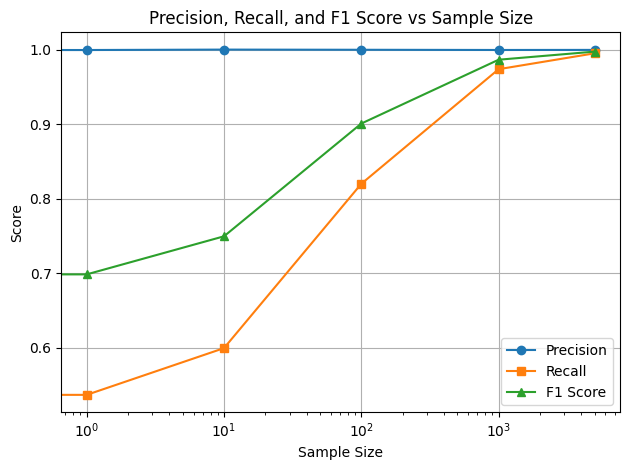

In [11]:
# Visualization
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = [0, 1, 10, 100, 1000, 5000]

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_tcp_index)
    rng.shuffle(test_tcp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, udp_index])
    print(len(combined_index), "samples in combined index.")
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_udp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_udp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]
        
        # Meta-train: all UDPFlood + 80% Benign
        meta_train_index = np.concatenate([train_udp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        
        # Count number of 0 and 1 in y_meta_train
        meta_train_num_zeros = (y_meta_train == 0).sum().item()
        meta_train_num_ones = (y_meta_train == 1).sum().item()
        print(f"y_meta_train: {meta_train_num_zeros} zeros, {meta_train_num_ones} ones")

        # Meta-test: len_meta_test samples from TCP + 20% Benign
        meta_test_index = np.concatenate([
            train_tcp_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

        # Count number of 0 and 1 in y_meta_test
        meta_test_num_zeros = (y_meta_test == 0).sum().item()
        meta_test_num_ones = (y_meta_test == 1).sum().item()
        print(f"y_meta_test: {meta_test_num_zeros} zeros, {meta_test_num_ones} ones")

        # Test set: 1000 samples from TCP, UDP and 2000 Benign
        test_index = np.concatenate([
            test_tcp_index[:1000], 
            test_udp_index[:1000], 
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for len_meta_test: 0
950983 samples in combined index.
y_meta_train: 305820 zeros, 378510 ones
y_meta_test: 76456 zeros, 0 ones
y_meta_train: 305734 zeros, 378618 ones
y_meta_test: 76434 zeros, 0 ones
y_meta_train: 305846 zeros, 378478 ones
y_meta_test: 76462 zeros, 0 ones
y_meta_train: 305513 zeros, 378895 ones
y_meta_test: 76379 zeros, 0 ones
y_meta_train: 305843 zeros, 378483 ones
y_meta_test: 76461 zeros, 0 ones
F1 Score: 0.7025 ± 0.0007
Running for len_meta_test: 1
950983 samples in combined index.
y_meta_train: 305820 zeros, 378510 ones
y_meta_test: 76456 zeros, 1 ones
y_meta_train: 305734 zeros, 378618 ones
y_meta_test: 76434 zeros, 1 ones
y_meta_train: 305846 zeros, 378478 ones
y_meta_test: 76462 zeros, 1 ones
y_meta_train: 305513 zeros, 378895 ones
y_meta_test: 76379 zeros, 1 ones
y_meta_train: 305843 zeros, 378483 ones
y_meta_test: 76461 zeros, 1 ones
F1 Score: 0.6973 ± 0.0020
Running for len_meta_test: 10
950983 samples in combined index.
y_meta_train: 305820 zeros, 

In [13]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different alphas
for alpha in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    len_meta_test = 1000
    print(f"Running for alpha: {alpha}")
    
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=int(alpha * 1000))  # Use alpha to seed the RNG
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_tcp_index)
    rng.shuffle(test_tcp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, udp_index])
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_udp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_udp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]
        
        # Meta-train: all UDPFlood + 80% Benign
        meta_train_index = np.concatenate([train_udp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        
        # Meta-test: len_meta_test samples from TCP + 20% Benign
        meta_test_index = np.concatenate([
            train_tcp_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

        # Test set: 1000 samples from TCP, UDP and 2000 Benign
        test_index = np.concatenate([
            test_tcp_index[:1000], 
            test_udp_index[:1000], 
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=alpha)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for alpha: 0.0
F1 Score: 0.6622 ± 0.0039
Running for alpha: 0.1
F1 Score: 0.9866 ± 0.0047
Running for alpha: 0.2
F1 Score: 0.9921 ± 0.0024
Running for alpha: 0.3
F1 Score: 0.9910 ± 0.0021
Running for alpha: 0.4
F1 Score: 0.9887 ± 0.0029
Running for alpha: 0.5
F1 Score: 0.9902 ± 0.0036
Running for alpha: 0.6
F1 Score: 0.9861 ± 0.0028
Running for alpha: 0.7
F1 Score: 0.9859 ± 0.0030
Running for alpha: 0.8
F1 Score: 0.9765 ± 0.0038
Running for alpha: 0.9
F1 Score: 0.9517 ± 0.0049
Running for alpha: 1.0
F1 Score: 0.6978 ± 0.0013


F1 Scores:
0.6622 ± 0.0039
0.9866 ± 0.0047
0.9921 ± 0.0024
0.9910 ± 0.0021
0.9887 ± 0.0029
0.9902 ± 0.0036
0.9861 ± 0.0028
0.9859 ± 0.0030
0.9765 ± 0.0038
0.9517 ± 0.0049
0.6978 ± 0.0013
Precisions:
0.9998 ± 0.0004
0.9996 ± 0.0006
0.9990 ± 0.0005
0.9994 ± 0.0006
0.9992 ± 0.0003
0.9996 ± 0.0004
0.9992 ± 0.0008
0.9994 ± 0.0005
0.9994 ± 0.0002
0.9986 ± 0.0005
0.9983 ± 0.0012
Recalls:
0.4951 ± 0.0043
0.9740 ± 0.0087
0.9853 ± 0.0046
0.9828 ± 0.0040
0.9784 ± 0.0056
0.9811 ± 0.0067
0.9734 ± 0.0058
0.9727 ± 0.0060
0.9547 ± 0.0073
0.9090 ± 0.0087
0.5364 ± 0.0012


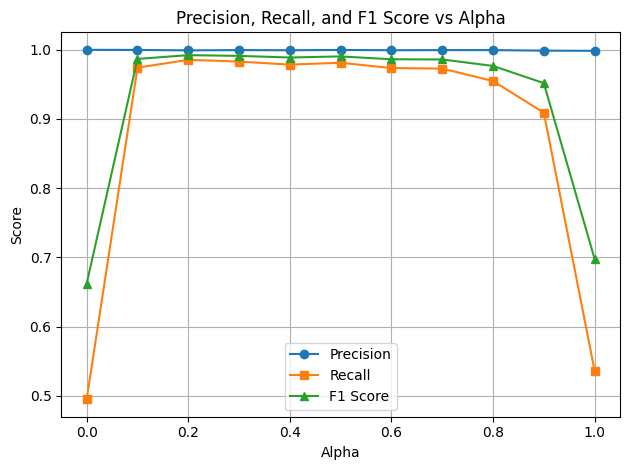

In [14]:
# Visualization
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs Alpha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
f1_scores_udp = []
f1_scores_std_udp = []
precisions_udp = []
precisions_std_udp = []
recalls_udp = []
recalls_std_udp = []

f1_scores_udp_tcp = []
f1_scores_std_udp_tcp = []
precisions_udp_tcp = []
precisions_std_udp_tcp = []
recalls_udp_tcp = []
recalls_std_udp_tcp = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test ** 2)
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_tcp_index)
    rng.shuffle(test_tcp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores_udp = []
    fold_precisions_udp = []
    fold_recalls_udp = []
    
    fold_f1_scores_udp_tcp = []
    fold_precisions_udp_tcp = []
    fold_recalls_udp_tcp = []

    combined_index = np.concatenate([benign_index, udp_index])
    print(len(combined_index), "samples in combined index.")
    print("Number of ones in y_processed[combined_index]:", np.sum(y_processed[combined_index] == 1))
    print("Number of zeros in y_processed[combined_index]:", np.sum(y_processed[combined_index] == 0))
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = np.intersect1d(train_index, benign_index)
        train_udp_index = np.intersect1d(train_index, udp_index)
        test_benign_index = np.intersect1d(test_index, benign_index)
        test_udp_index = np.intersect1d(test_index, udp_index)

        # Split into 50% and 50%    
        len_train_udp_50 = int(0.50 * len(train_udp_index))
        
        # Split into 33%, 33% and 34%    
        len_train_benign_33 = int(0.33 * len(train_benign_index))
        len_train_benign_66 = int(0.66 * len(train_benign_index))

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        #--------------------------------- Training with UDP only ---------------------------------------#
        # Train: 50% UDP + 50% Benign
        udp_train_index = np.concatenate([train_udp_index[:len_train_udp_50], train_benign_index[:len_train_benign_33]])
        x_train = torch.tensor(X_processed[udp_train_index], dtype=torch.float32)
        y_train = torch.tensor(y_processed[udp_train_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[udp_train_index]:", np.sum(y_processed[udp_train_index] == 1))
        print("Number of zeros in y_processed[udp_train_index]:", np.sum(y_processed[udp_train_index] == 0))

        # Training with UDP only
        for epoch in range(1000):
            loss = normal_train_step(model, x_train, y_train, optimizer)

        # Evaluation with UDP only
        with torch.no_grad():
            udp_test_index = np.concatenate([test_benign_index[:1000], test_udp_index[:1000]])
            x_test = torch.tensor(X_processed[udp_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[udp_test_index], dtype=torch.float32).unsqueeze(1)
            print("Number of ones in y_processed[udp_test_index]:", np.sum(y_processed[udp_test_index] == 1))
            print("Number of zeros in y_processed[udp_test_index]:", np.sum(y_processed[udp_test_index] == 0))

            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores_udp.append(score)
            fold_precisions_udp.append(precision)
            fold_recalls_udp.append(recall)
            

        #--------------------------------- Training with UDP and TCP ---------------------------------------#
        # Meta-train: 50% UDPFlood + 25% Benign
        udp_tcp_meta_train_index = np.concatenate([train_udp_index[len_train_udp_50:], train_benign_index[len_train_benign_33:len_train_benign_66]])
        x_meta_train = torch.tensor(X_processed[udp_tcp_meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[udp_tcp_meta_train_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[udp_tcp_meta_train_index]:", np.sum(y_processed[udp_tcp_meta_train_index] == 1))
        print("Number of zeros in y_processed[udp_tcp_meta_train_index]:", np.sum(y_processed[udp_tcp_meta_train_index] == 0))

        # Meta-test: len_meta_test samples from TCP and 15% Benign
        udp_tcp_meta_test_index = np.concatenate([
            train_tcp_index[:len_meta_test], 
            train_benign_index[len_train_benign_66:]
        ])
        x_meta_test = torch.tensor(X_processed[udp_tcp_meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[udp_tcp_meta_test_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[udp_tcp_meta_train_index]:", np.sum(y_processed[udp_tcp_meta_train_index] == 1))
        print("Number of zeros in y_processed[udp_tcp_meta_train_index]:", np.sum(y_processed[udp_tcp_meta_train_index] == 0))

        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer)
            
        # Evaluation
        with torch.no_grad():
            udp_tcp_test_index = np.concatenate([test_benign_index[:2000], test_udp_index[:1000], test_tcp_index[:1000]])
            x_test= torch.tensor(X_processed[udp_tcp_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[udp_tcp_test_index], dtype=torch.float32).unsqueeze(1)
            print("Number of ones in y_processed[udp_tcp_test_index]:", np.sum(y_processed[udp_tcp_test_index] == 1))
            print("Number of zeros in y_processed[udp_tcp_test_index]:", np.sum(y_processed[udp_tcp_test_index] == 0))

            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores_udp_tcp.append(score)
            fold_precisions_udp_tcp.append(precision)
            fold_recalls_udp_tcp.append(recall)
        

    f1_scores_udp.append(np.mean(fold_f1_scores_udp))
    precisions_udp.append(np.mean(fold_precisions_udp))
    recalls_udp.append(np.mean(fold_recalls_udp))
    f1_scores_std_udp.append(np.std(fold_f1_scores_udp))
    precisions_std_udp.append(np.std(fold_precisions_udp))
    recalls_std_udp.append(np.std(fold_recalls_udp))  

    f1_scores_udp_tcp.append(np.mean(fold_f1_scores_udp_tcp))
    precisions_udp_tcp.append(np.mean(fold_precisions_udp_tcp))
    recalls_udp_tcp.append(np.mean(fold_recalls_udp_tcp))
    f1_scores_std_udp_tcp.append(np.std(fold_f1_scores_udp_tcp))
    precisions_std_udp_tcp.append(np.std(fold_precisions_udp_tcp))
    recalls_std_udp_tcp.append(np.std(fold_recalls_udp_tcp))

    print(f"F1 Score of M1 (UDP only): {f1_scores_udp[-1]:.4f} ± {f1_scores_std_udp[-1]:.4f}")
    print(f"F1 Score of M2 (UDP + TCP): {f1_scores_udp_tcp[-1]:.4f} ± {f1_scores_std_udp_tcp[-1]:.4f}")

Running for len_meta_test: 0
950983 samples in combined index.
Number of ones in y_processed[combined_index]: 473246
Number of zeros in y_processed[combined_index]: 477737
Number of ones in y_processed[udp_train_index]: 189255
Number of zeros in y_processed[udp_train_index]: 126151
Number of ones in y_processed[udp_test_index]: 1000
Number of zeros in y_processed[udp_test_index]: 1000
Number of ones in y_processed[udp_tcp_meta_train_index]: 189255
Number of zeros in y_processed[udp_tcp_meta_train_index]: 126151
Number of ones in y_processed[udp_tcp_meta_train_index]: 189255
Number of zeros in y_processed[udp_tcp_meta_train_index]: 126151
Number of ones in y_processed[udp_tcp_test_index]: 2000
Number of zeros in y_processed[udp_tcp_test_index]: 2000
Number of ones in y_processed[udp_train_index]: 189309
Number of zeros in y_processed[udp_train_index]: 126115
Number of ones in y_processed[udp_test_index]: 1000
Number of zeros in y_processed[udp_test_index]: 1000
Number of ones in y_proce

F1 Scores of M1 (UDP only):
F1 Scores:
0.9989 ± 0.0006
0.9986 ± 0.0006
0.9985 ± 0.0008
0.9986 ± 0.0009
0.9983 ± 0.0005
0.9986 ± 0.0006
Precisions:
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
1.0000 ± 0.0000
Recalls:
0.9978 ± 0.0012
0.9972 ± 0.0012
0.9970 ± 0.0017
0.9972 ± 0.0017
0.9966 ± 0.0010
0.9972 ± 0.0012
F1 Scores of M2 (UDP + TCP):
F1 Scores:
0.4683 ± 0.2360
0.5094 ± 0.0389
0.5435 ± 0.0615
0.8257 ± 0.0560
0.9424 ± 0.0224
0.9840 ± 0.0190
Precisions:
0.8000 ± 0.4000
0.9997 ± 0.0005
0.9994 ± 0.0007
0.9997 ± 0.0005
0.9999 ± 0.0002
0.9997 ± 0.0004
Recalls:
0.3317 ± 0.1684
0.3427 ± 0.0346
0.3757 ± 0.0577
0.7071 ± 0.0787
0.8921 ± 0.0406
0.9695 ± 0.0362


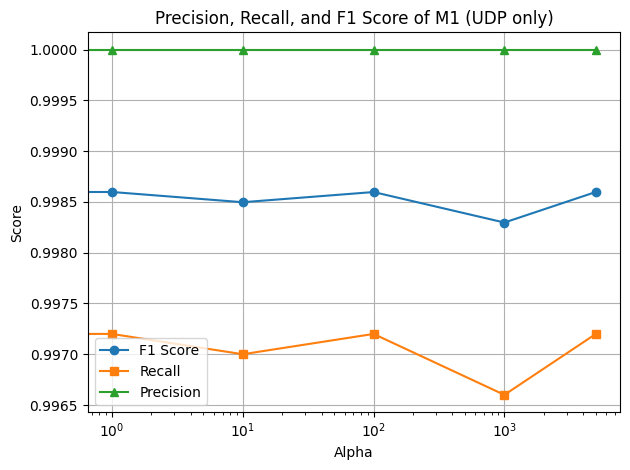

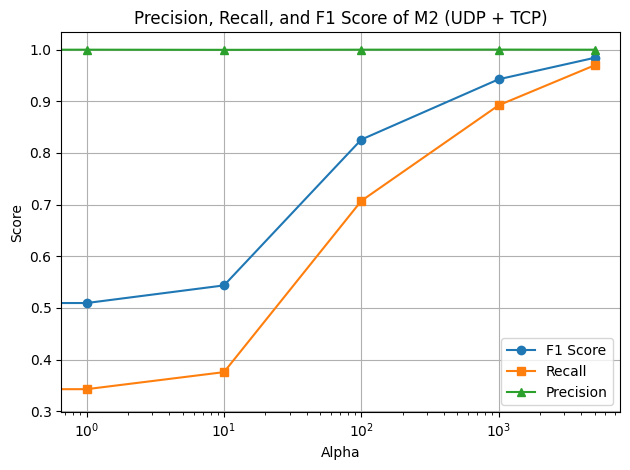

In [20]:
# Visualization
print("F1 Scores of M1 (UDP only):")
print("F1 Scores:")
for i in range(len(f1_scores_udp)):
    print(f"{f1_scores_udp[i]:.4f} ± {f1_scores_std_udp[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_udp)):
    print(f"{precisions_udp[i]:.4f} ± {precisions_std_udp[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls_udp)):
    print(f"{recalls_udp[i]:.4f} ± {recalls_std_udp[i]:.4f}")

print("F1 Scores of M2 (UDP + TCP):")
print("F1 Scores:")
for i in range(len(f1_scores_udp_tcp)):
    print(f"{f1_scores_udp_tcp[i]:.4f} ± {f1_scores_std_udp_tcp[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_udp_tcp)):
    print(f"{precisions_udp_tcp[i]:.4f} ± {precisions_std_udp_tcp[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls_udp_tcp)):
    print(f"{recalls_udp_tcp[i]:.4f} ± {recalls_std_udp_tcp[i]:.4f}")

x = [0, 1, 10, 100, 1000, 5000]

plt.plot(x, f1_scores_udp, marker='o', label='F1 Score')
plt.plot(x, recalls_udp, marker='s', label='Recall')
plt.plot(x, precisions_udp, marker='^', label='Precision')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M1 (UDP only)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.plot(x, f1_scores_udp_tcp, marker='o', label='F1 Score')
plt.plot(x, recalls_udp_tcp, marker='s', label='Recall')
plt.plot(x, precisions_udp_tcp, marker='^', label='Precision')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M2 (UDP + TCP)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()